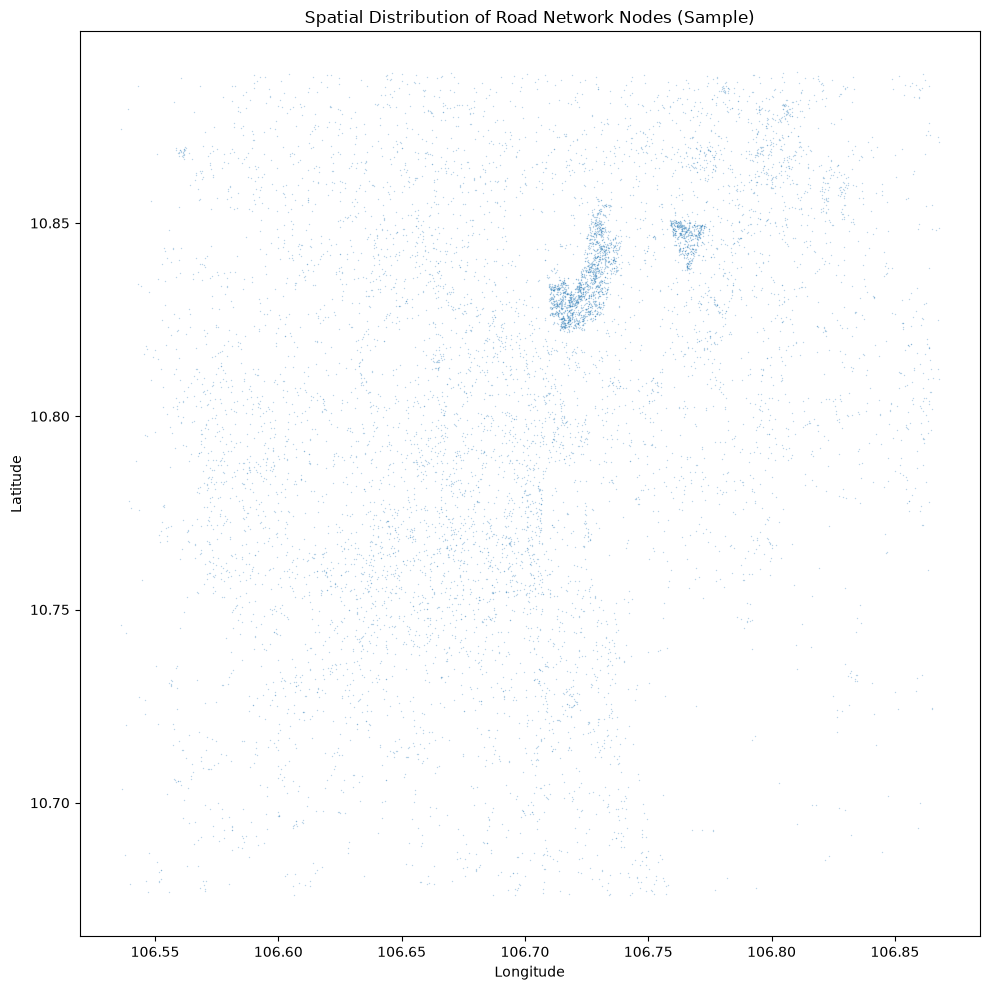

In [4]:
# Spatial Distribution of Nodes
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "dataset/nodes.csv"
nodes_df = pd.read_csv(file_path)

sample_nodes = nodes_df.sample(n=10000, random_state=1)

plt.figure(figsize=(10, 10))
sns.scatterplot(data=sample_nodes, x='long', y='lat', s=1, alpha=0.3)

plt.title('Spatial Distribution of Road Network Nodes (Sample)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()

plt.show()
plt.close()

/tmp/ipykernel_8067/2349237587.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='LOS', order=los_order, palette='viridis')


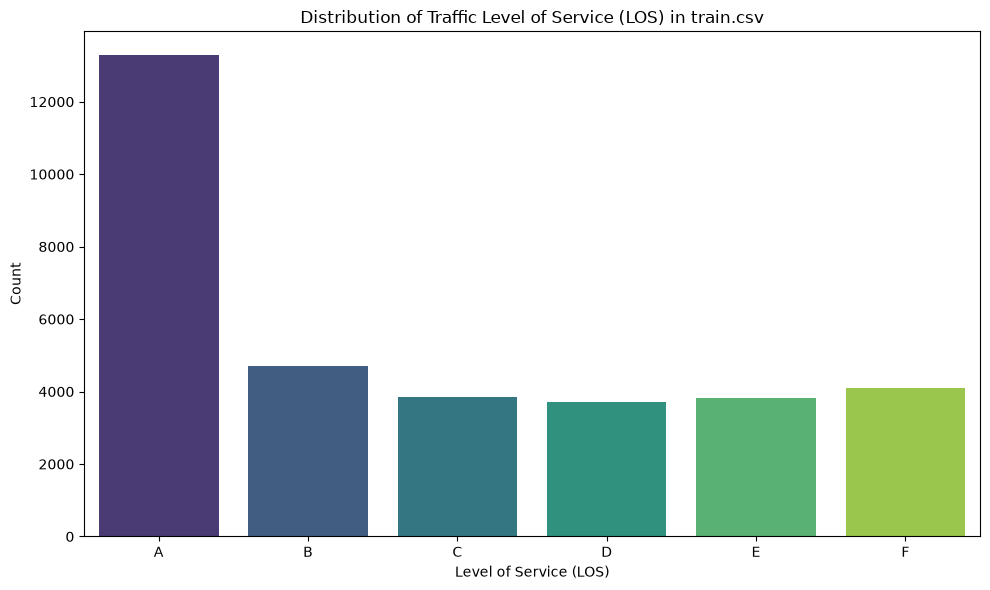

In [3]:
# LOS Distribution
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "dataset/train.csv"
train_df = pd.read_csv(file_path)

plt.figure(figsize=(10, 6))

los_order = sorted(train_df['LOS'].unique())

sns.countplot(data=train_df, x='LOS', order=los_order, palette='viridis')

plt.title('Distribution of Traffic Level of Service (LOS) in train.csv')
plt.xlabel('Level of Service (LOS)')
plt.ylabel('Count')
plt.tight_layout()

plt.show()
plt.close()

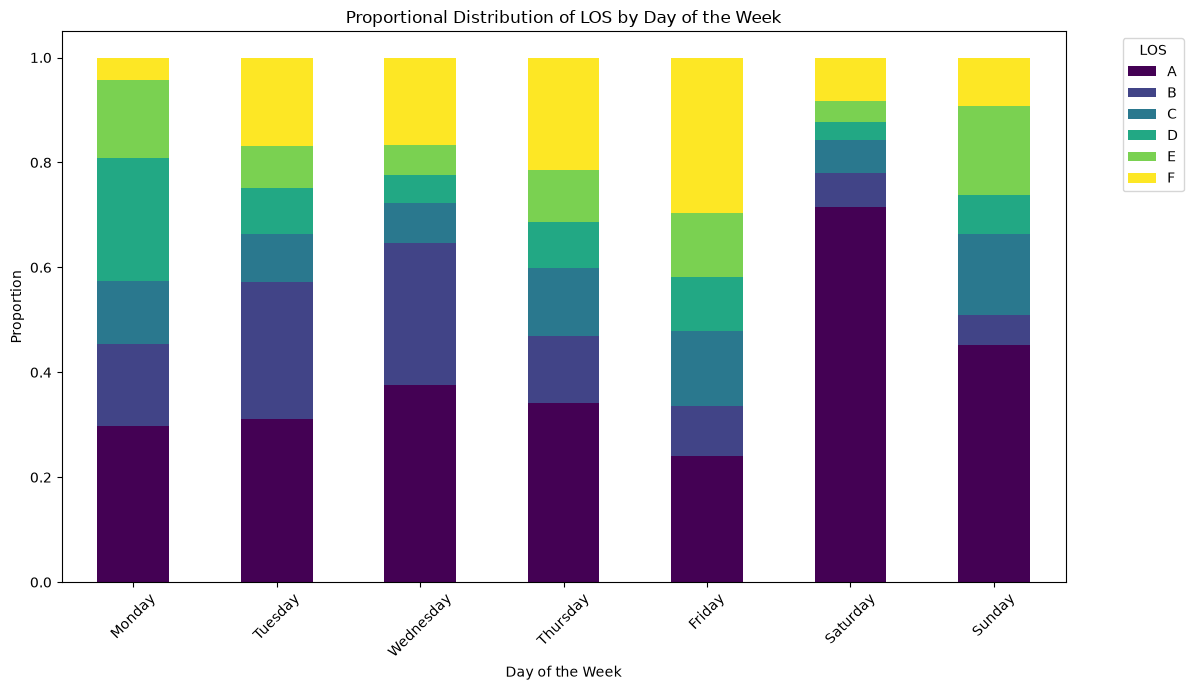

In [7]:
# LOS by Weekday
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

weekday_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
train_df['weekday_name'] = train_df['weekday'].map(weekday_map)

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

los_by_weekday = train_df.groupby('weekday_name')['LOS'].value_counts(normalize=True).unstack().fillna(0)

los_by_weekday = los_by_weekday.reindex(weekday_order)

los_by_weekday.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

plt.title('Proportional Distribution of LOS by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Proportion')
plt.legend(title='LOS', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()
plt.close()

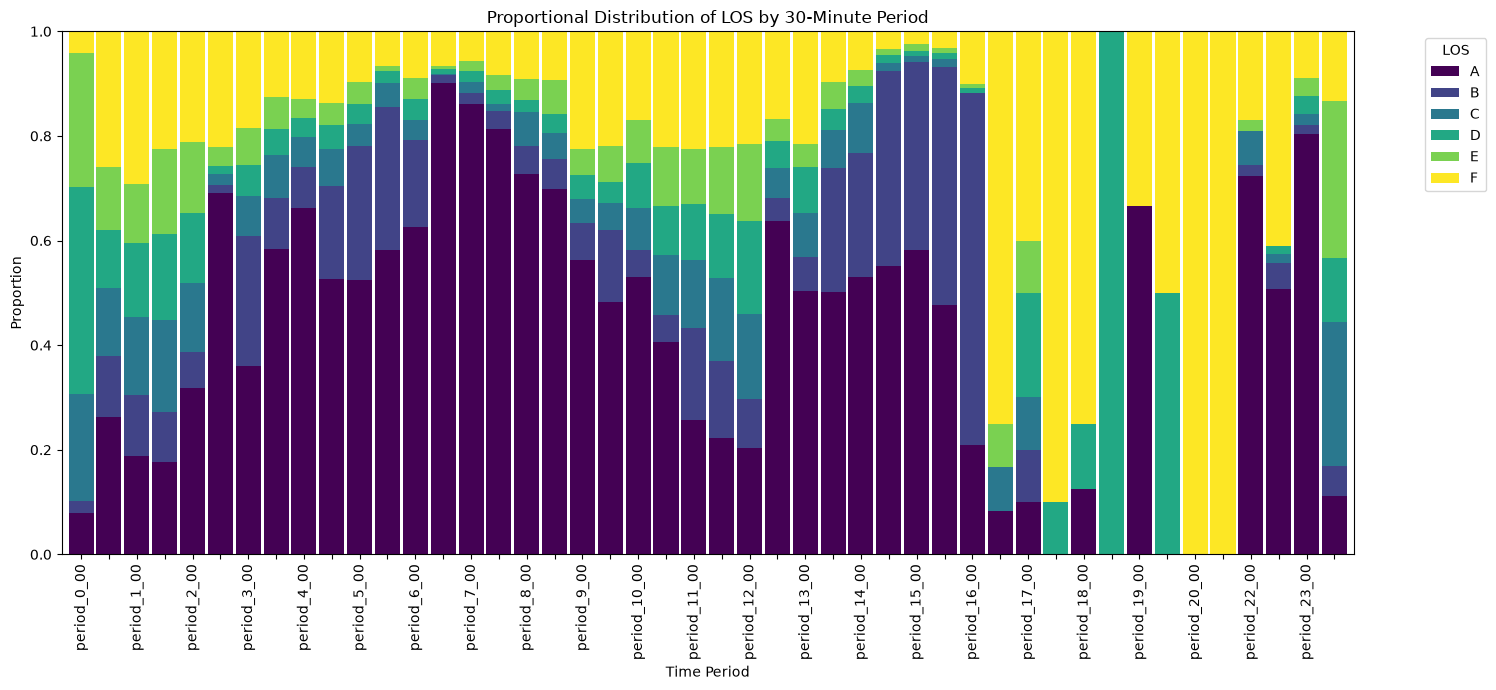

In [ ]:
# LOS by Time Period
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def extract_period_sort_key(period_str):
    parts = period_str.split('_')
    hour = int(parts[1])
    minute = int(parts[2])
    return hour * 60 + minute

train_df['period_sort_key'] = train_df['period'].apply(extract_period_sort_key)
period_order = train_df.drop_duplicates('period').sort_values('period_sort_key')['period']

los_by_period = train_df.groupby('period')['LOS'].value_counts(normalize=True).unstack().fillna(0)

los_by_period = los_by_period.reindex(period_order)

los_by_period.plot(kind='bar', stacked=True, figsize=(15, 7), colormap='viridis', width=0.9)

plt.title('Proportional Distribution of LOS by 30-Minute Period')
plt.xlabel('Time Period')
plt.ylabel('Proportion')
plt.legend(title='LOS', bbox_to_anchor=(1.05, 1), loc='upper left')

ax = plt.gca()
n = 2 
ticks = ax.get_xticks()
labels = [label.get_text() if i % n == 0 else '' for i, label in enumerate(ax.get_xticklabels())]
ax.set_xticks(ticks)
ax.set_xticklabels(labels, rotation=90)

plt.tight_layout()

plt.show()
plt.close()

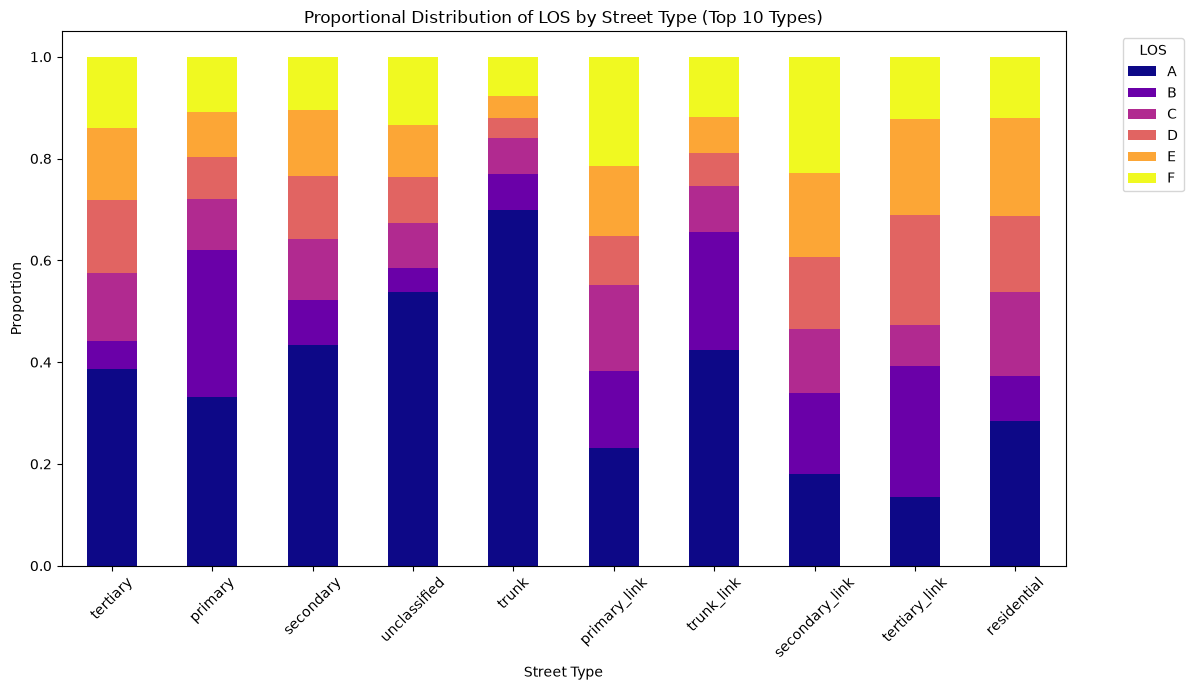

In [6]:
# LOS by Street Type
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

top_street_types = train_df['street_type'].value_counts().head(10).index.tolist()

df_top_streets = train_df[train_df['street_type'].isin(top_street_types)]

los_by_street_type = df_top_streets.groupby('street_type')['LOS'].value_counts(normalize=True).unstack().fillna(0)

los_by_street_type = los_by_street_type.reindex(top_street_types)

los_by_street_type.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='plasma')

plt.title('Proportional Distribution of LOS by Street Type (Top 10 Types)')
plt.xlabel('Street Type')
plt.ylabel('Proportion')
plt.legend(title='LOS', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()
plt.close()